# Gaussian Process tool

This notebook is a walkthrough for the pipeline used by the GP reconstruction code

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Settings

Here we specify the fixed settings of the reconstruction, namely the number and distribution of the $x$ points where the reconstruction is performed

In [3]:
N_recon    = 20
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

# Theoretical function

In [4]:
def get_theory(coeffs):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(coeffs)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}
    return results

# Create data to be reconstructed

Here we simulate data and errors for a completely made up observable

$$f(x) = \sum_{i=0}^N{a_ix^i}$$

where $N$ is the order of the polynomial and $a_i$ are the parameters controlling the $x$ trend of the observable

### Data settings

Settings controlling the data quality: number of measurements and their error

In [5]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

### Theory model

In [6]:
fiducial = {'a0': 3,
            'a1': -1,
            #'a2': 5,
            #'a3': -0.1
           }

theory_model = get_theory(list(fiducial.values()))

### Data generation

In [7]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

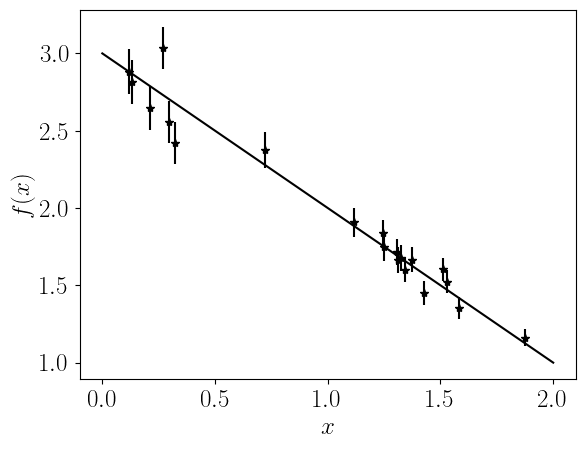

In [8]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
plt.plot(xplot,theory_model['f'](xplot),color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Gaussian process

A Gaussian Process (GP) is the generalisation of a Gaussian distribution where, instead of looking at a random variable, we look at a distribution over functions.

Given a set of observational data $\mathbf{y}$ at positions $\mathbf{X}=\{x_i\}$, in the GP approach we assume that these are Gaussian representation of the underlying function $f(x)$

$$\mathbf{y}\sim\mathcal{N}(\mathbf{\mu},K(\mathbf{X},\mathbf{X})+C)\,,$$

where $\mathbf{\mu}$ is the mean of the distribution, $K(\mathbf{X},\mathbf{X})$ is the covariance matrix of the normal distribution and $C$ is the observational covariance which accounts for the measurement error.

This means that a new vector of values $\mathbf{f}^*$ for the underlying function at a set of points $\mathbf{X}^*$ can be written as 

$$\mathbf{f}^*\sim\mathcal{N}(\mathbf{\mu}^*,K(\mathbf{X}^*,\mathbf{X}^*))\,.$$

Jointly, the two GP for $\mathbf{y}$ and $\mathbf{f}^*$ can be written as

$$\begin{bmatrix} \mathbf{y} \\ \mathbf{f}^* \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mathbf{\mu} \\ \mathbf{\mu}^* \end{bmatrix}, \begin{bmatrix} K(\mathbf{X},\mathbf{X}) + C & K(\mathbf{X},\mathbf{X}^*) \\ K(\mathbf{X}^*,\mathbf{X}) & K(\mathbf{X}^*,\mathbf{X}^*) \end{bmatrix} \right)$$

The $\mathbf{y}$ points are known from observations, while we want to obtain the values of $\mathbf{f}^*$.

The mean and covariance of these values can be obtained as **REF**

$$\mathbf{f}^* = K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

$$\text{cov}(\mathbf{f}^*) = K(\mathbf{X}^*,\mathbf{X}^*) - K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} K(\mathbf{X}^*,\mathbf{X})$$


where we assumed $\mathbf{\mu}=\mathbf{\mu}^*=0$. (**explain why this is good**)


In the context of GP, the covariance $K$ is known as *Kernel* and can be chosen between different possibilities. Kernels contain some free parameters known as *hyper-parameters*.


Choosing the hyper-parameters (see below) and a Kernel, one can therefore obtain predictions for the target function at a set of $\mathbf{X}^*$ points, based on the observed $\mathbf{y}$.

Aside from the usefullness of reconstructing the target function, GP have another very useful property: the result of performing a linear operation on a GP returns a function that is still a GP **REF**.

This means that if we want to obtain the derivative of the target function (${\rm d}\,f/{\rm d}\,x$), once we reconstruct the function $f(x)$ with a GP, the derivative can be rewritten as

$$\mathbf{f}'^* = \frac{\partial K(\mathbf{X},\mathbf{X}^*)}{\partial \mathbf{X}_*} (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

with the derivative covariance being

$$\text{cov}(f'(x), f'(x')) = \frac{\partial^2}{\partial x \partial x'} k(x, x')$$

and the covariance between the function and the derivative being

$$\text{cov}(f(x), f'(x')) = \frac{\partial}{\partial x'} k(x, x')$$

This holds not just for the first derivative but also for higher orders (as long as one can obtain derivatives of the kernel) and integrals. We refer to **REF** for a more extended discussion

## The GP class: GPCalculator

The main code allowing to use GP to reconstruct a given function is contained in `reconstruction_tools/GaussianProcess.py`, which contains the `GPCalculator` class.

blablabla

In [9]:
from reconstruction_tools.GaussianProcess import GPCalculator

## Choosing hyper-parameters

The choice of hyper-parameters can be handled by the GPCalculator class, which offers the possibility
to switch between an optimization approach and a marginalization approach.

For this example we fix the kernel to RBF

In [10]:
reconstructions = {}

In [11]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF')

### Optimized

**Explain optimization here**

In [12]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Optimized'] = {'Functions': means,
                                'Covmat': joint_cov}

best_fit = info['Best-fit']

best_fit['logl']     = np.log(best_fit['l'])
best_fit['logsigma'] = np.log(best_fit['sigmas'][0])

GP done in 11.66 s


### Marginalized

**Explain marginalization here**

In [13]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Marginalized'] = {'Functions': means,
                                   'Covmat': joint_cov}

sample = info['sample']

Removed no burn in
GP done in 350.30 s


### Visualize hyper-parameters

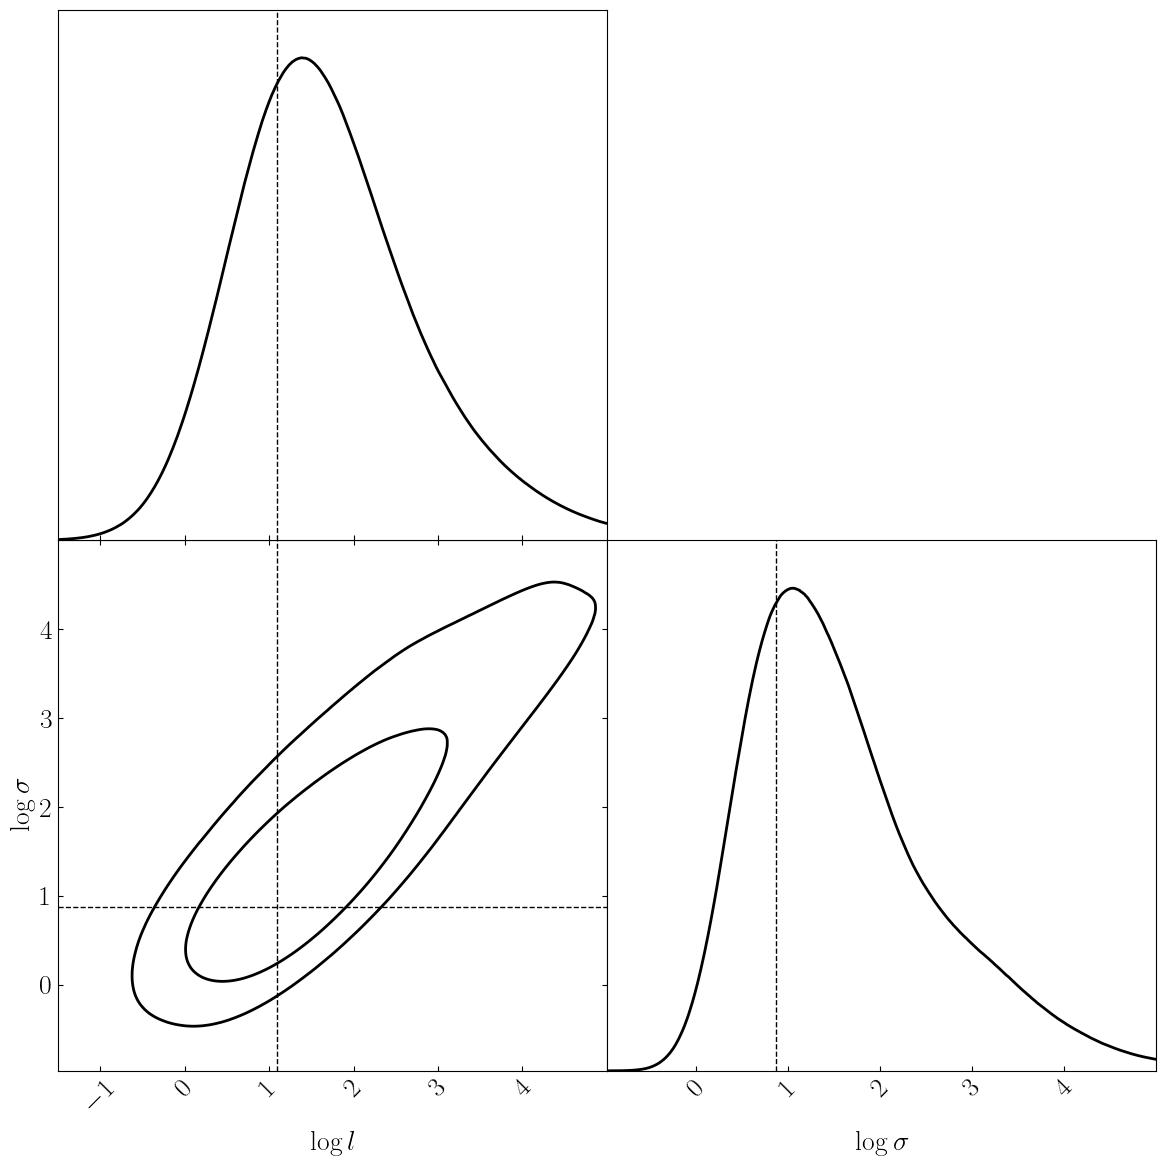

In [14]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['logl','logsigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Comparison

In [15]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

In [16]:
results

,x,f,d1,d2,int,f_err,d1_err,d2_err,int_err,Method
0,0.000000,2.825847,-0.627013,-0.446765,0.000000,0.242990,0.344841,0.327921,0.000000,Optimized
1,0.105263,2.757409,-0.672938,-0.425477,0.293898,0.219236,0.319513,0.333514,0.024286,Optimized
2,0.210526,2.684258,-0.716517,-0.402188,0.580342,0.198729,0.294451,0.338660,0.046167,Optimized
3,0.315789,2.606653,-0.757544,-0.377034,0.858848,0.181267,0.270158,0.343240,0.065892,Optimized
4,0.421053,2.524872,-0.795832,-0.350167,1.128963,0.166529,0.247278,0.347157,0.083690,Optimized
5,0.526316,2.439212,-0.831209,-0.321749,1.390263,0.154089,0.226636,0.350328,0.099754,Optimized
6,0.631579,2.349988,-0.863520,-0.291953,1.642354,0.143470,0.209249,0.352692,0.114247,Optimized
7,0.736842,2.257530,-0.892631,-0.260964,1.884880,0.134211,0.196268,0.354203,0.127297,Optimized
8,0.842105,2.162182,-0.918425,-0.228973,2.117518,0.125960,0.188808,0.354833,0.138997,Optimized
9,0.947368,2.064297,-0.940807,-0.196178,2.339983,0.118562,0.187624,0.354573,0.149411,Optimized


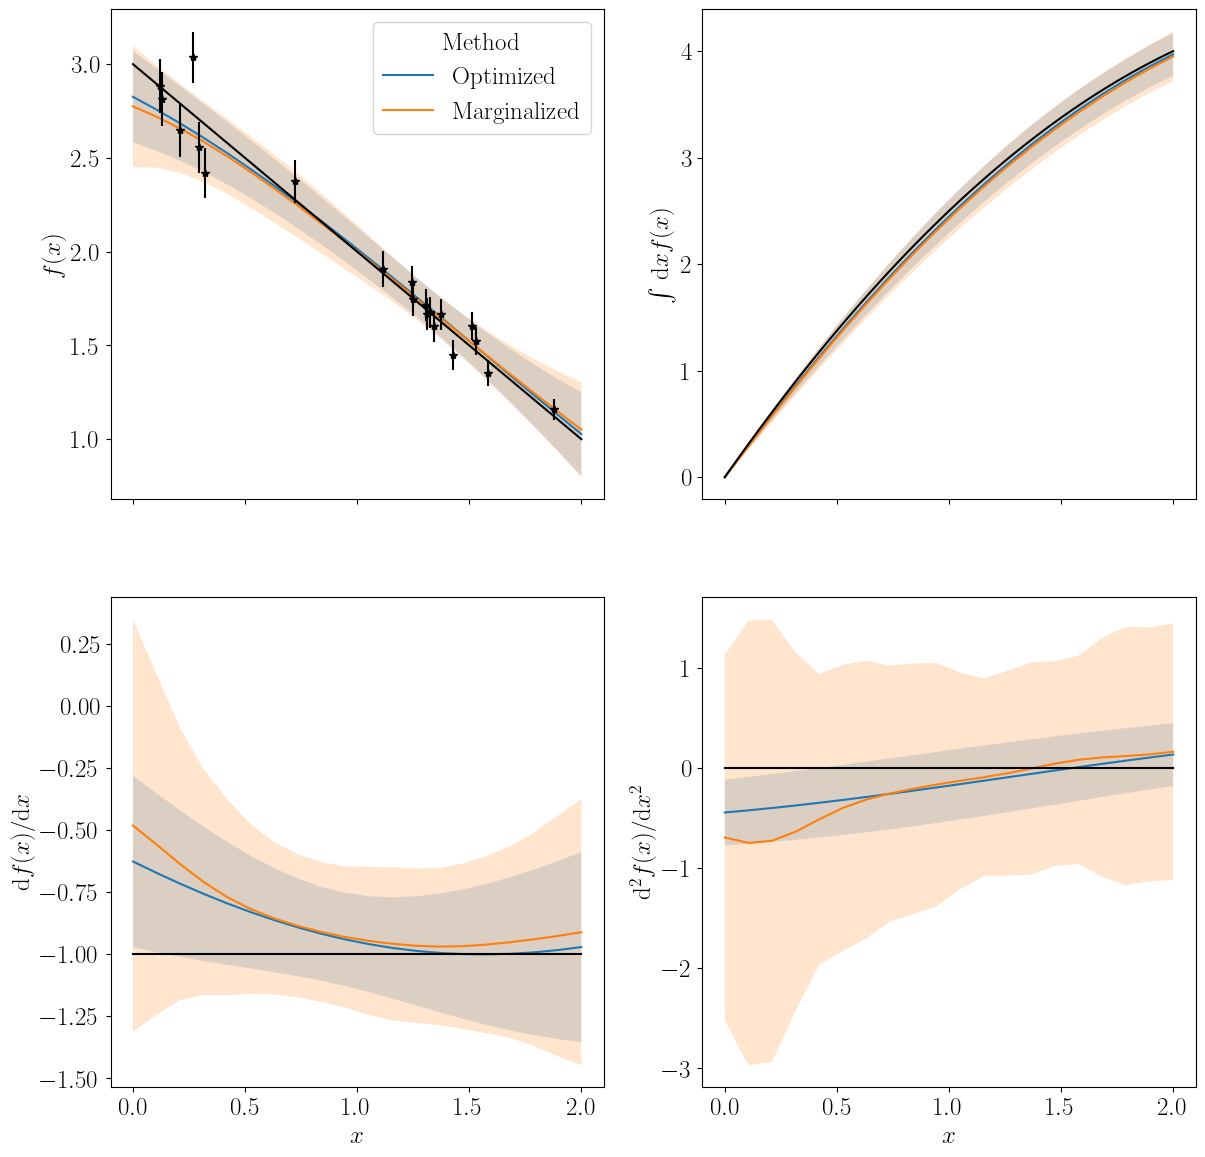

In [17]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    axes[i,j].plot(xplot,theory_model[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Available kernels

**Explain kernels here**

In [18]:
available_kernels = ['RBF','MATERN3/2','MATERN5/2']

### Comparison

# GP diagnostics

**EXPLAIN DIAGNOSTICS HERE**

In [19]:
from utils.diagnostics import Scorer

In [20]:
score = {}

In [21]:
for k,v in reconstructions.items():
    score[k] = Scorer(v['Functions'],v['Covmat'],chatty=True)

## Theory score

Here we test against a fiducial function...

In [22]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory_model[func](x_recon) for func in ['f','d1','d2','int']})

###  Malahanobis distance

Explain full $\chi^2$ and what we see here

In [23]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_theory(theory_df)


Optimized

 SCORE REPORT: THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 10.18
Red.  Chi2: 0.127
P-value:    1.0000
DOF:        80


Marginalized

 SCORE REPORT: THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 0.78
Red.  Chi2: 0.010
P-value:    1.0000
DOF:        80



### Diagonal distance

Explain diagonal $\chi^2$ and what we see here

In [24]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_pointwise(theory_df)


Optimized

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 21.82
Red.  Chi2: 0.273
P-value:    1.0000
DOF:        80


Marginalized

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 9.51
Red.  Chi2: 0.119
P-value:    1.0000
DOF:        80



## Comparison with data

In [25]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [26]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_data(datasets)


Optimized

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status: GOOD (Consistent)
Total Chi2: 1.23
Red.  Chi2: 0.061
P-value:    1.0000
DOF:        20


Marginalized

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status: GOOD (Consistent)
Total Chi2: 1.25
Red.  Chi2: 0.063
P-value:    1.0000
DOF:        20



# Gaussian Process reconstruction for correlated data

The GP module of CoRe is also able to handle reconstruction when the data from which reconstruct separate functions are correlated.

**EXPLAIN METHOD HERE**

Here we create the data for two functions $f_1(x)$ and $f_2(x)$ assuming including a correlation between the measurements of each function when they are performed at the same $x$. We assume the correlation factor to be uniformly distributed between 0 and 1 

In [27]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

In [28]:
fiducial_func1 = {'a0': 3,
                  'a1': -1}

theory_func_1 = get_theory(list(fiducial_func1.values()))

In [29]:
fiducial_func2 = {'a0': 3,
                  'a1': -1,
                  'a2': 5}

theory_func_2 = get_theory(list(fiducial_func2.values()))

In [30]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_func_1['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f1'] = np.random.normal(thvals,errors)
dataset['f1_err'] = errors

thvals = theory_func_2['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f2'] = np.random.normal(thvals,errors)
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0,1,len(dataset))
dataset

,x,f1,f1_err,f2,f2_err,"r(f1,f2)"
0,1.336244,1.610506,0.083188,10.527795,0.529575,0.450364
1,1.274868,1.762738,0.086257,9.834962,0.492579,0.032629
2,0.227656,2.869519,0.138617,3.070465,0.151574,0.087462
3,0.196001,3.035134,0.140200,3.112797,0.149804,0.102571
4,0.300549,2.719000,0.134973,2.993181,0.157555,0.052245
5,1.768125,1.264565,0.061594,16.138634,0.843161,0.322700
6,1.524025,1.403766,0.073799,13.622858,0.654462,0.996313
7,0.836950,2.269169,0.108153,5.673881,0.283274,0.969259
8,0.259231,2.545888,0.137038,3.137716,0.153839,0.419223
9,0.020136,2.934205,0.148993,2.920438,0.149095,0.626530


In [31]:
covmat_1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat_1.index = covmat_1.columns

covmat_2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat_2.index = covmat_2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_1.values,  cov_cross],
                         [cov_cross.T, covmat_2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

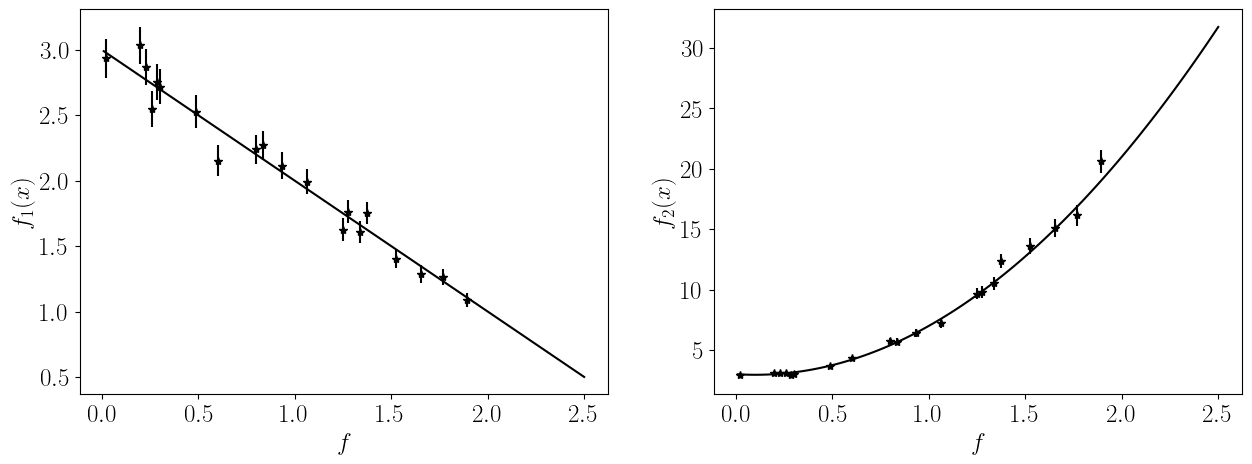

In [32]:
xplot = np.linspace(0.01,2.5,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))

axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$f$')
axes[0].set_ylabel(r'$f_1(x)$')

axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$f$')
axes[1].set_ylabel(r'$f_2(x)$');

In [33]:
reconstructions = {}

## Uncorrelated reconstruction

In [34]:
dataset_1 = dataset.copy()
dataset_1 = dataset_1[['x','f1','f1_err']].rename(columns={'f1': 'f','f1_err': 'f_err'})

In [35]:
gp = GPCalculator(dataset_1,covmat_1,kernel_type='RBF')
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Func1'] = {'Functions': means,
                            'Covmat': joint_cov}

Removed no burn in
GP done in 287.35 s


In [36]:
dataset_2 = dataset.copy()
dataset_2 = dataset_2[['x','f2','f2_err']].rename(columns={'f2': 'f','f2_err': 'f_err'})

In [37]:
gp = GPCalculator(dataset_2,covmat_2,kernel_type='RBF')
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Func2'] = {'Functions': means,
                            'Covmat': joint_cov}

Removed no burn in
GP done in 276.98 s


## Correlated reconstruction

In [38]:
dataset = dataset.drop(columns=['r(f1,f2)'])
gp = GPCalculator(dataset,covmat,kernel_type='RBF')
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Correlated'] = {'Functions': means,
                                 'Covmat': joint_cov}

Removed no burn in
GP done in 275.93 s


## Plotting

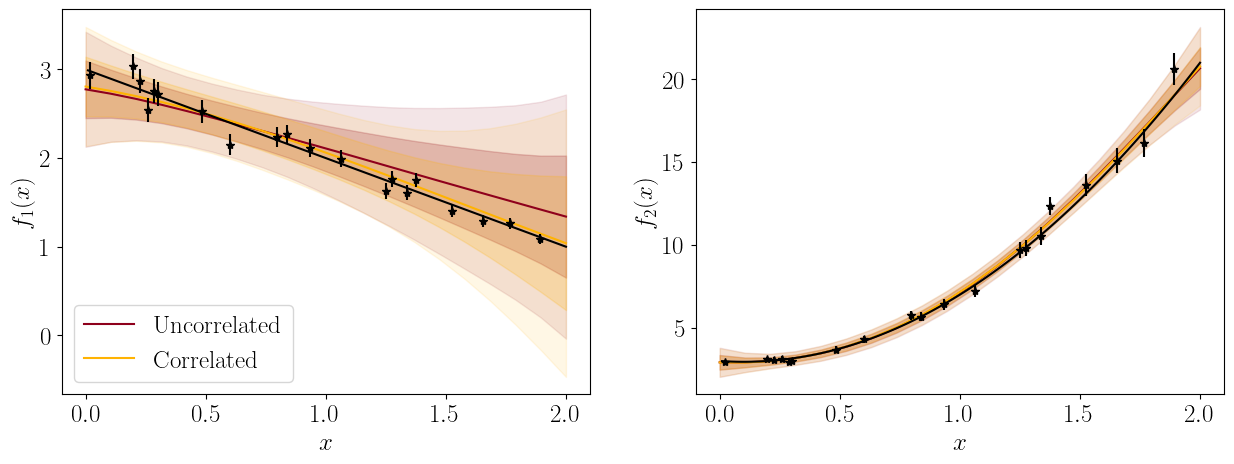

In [40]:
xplot = np.linspace(0.01,2.,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))
df =  reconstructions['Func1']['Functions']
axes[0].fill_between(df['x'],df['f']+2*df['f_err'],df['f']-2*df['f_err'],alpha=0.1,color=red)
axes[0].fill_between(df['x'],df['f']+df['f_err'],df['f']-df['f_err'],alpha=0.2,color=red)
axes[0].plot(df['x'],df['f'],color=red,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[0].fill_between(df['x'],df['f1']+2*df['f1_err'],df['f1']-2*df['f1_err'],alpha=0.1,color=yellow)
axes[0].fill_between(df['x'],df['f1']+df['f1_err'],df['f1']-df['f1_err'],alpha=0.2,color=yellow)
axes[0].plot(df['x'],df['f1'],color=yellow,label='Correlated')
axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f_1(x)$')
axes[0].legend(loc='best')



df =  reconstructions['Func2']['Functions']
axes[1].fill_between(df['x'],df['f']+2*df['f_err'],df['f']-2*df['f_err'],alpha=0.1,color=red)
axes[1].fill_between(df['x'],df['f']+df['f_err'],df['f']-df['f_err'],alpha=0.2,color=red)
axes[1].plot(df['x'],df['f'],color=red,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[1].fill_between(df['x'],df['f2']+2*df['f2_err'],df['f2']-2*df['f2_err'],alpha=0.1,color=yellow)
axes[1].fill_between(df['x'],df['f2']+df['f2_err'],df['f2']-df['f2_err'],alpha=0.2,color=yellow)
axes[1].plot(df['x'],df['f2'],color=yellow,label='Correlated')
axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$f_2(x)$');